In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")

# Если версия < 1.10.0, обновите:
# !pip install --upgrade torch torchvision

PyTorch version: 2.10.0+cu128


In [3]:
# ИМПОРТЫ

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from typing import List


In [4]:
print(f"Структура датасета:")
!ls -la "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000" | head -10

Структура датасета:
total 174
drwx------ 2 root root   4096 Mar 23 19:28 cat
-rw------- 1 root root 169473 Mar 25 10:08 dataset_index.csv
drwx------ 2 root root   4096 Mar 23 19:28 dog


In [5]:
# Путь к  папке
dataset_path = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
dataset_root = Path(dataset_path)

print(f"Сканирование: {dataset_root}")

# Сбор всех изображений из папок cat и dog
data = []

# Обработка папки с кошками
cat_folder = dataset_root / "cat"
if cat_folder.exists():
    for img_path in sorted(cat_folder.glob("*.*")):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            data.append({
                "path": str(img_path),
                "label": "cat",
                "label_num": 0,
                "filename": img_path.name,
                "ext": img_path.suffix.lower(),
            })
    print(f" Кошек найдено: {len([d for d in data if d['label'] == 'cat'])}")
else:
    print(f" Папка не найдена: {cat_folder}")

# Обработка папки с собаками
dog_folder = dataset_root / "dog"
if dog_folder.exists():
    for img_path in sorted(dog_folder.glob("*.*")):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            data.append({
                "path": str(img_path),
                "label": "dog",
                "label_num": 1,
                "filename": img_path.name,
                "ext": img_path.suffix.lower(),
            })
    print(f" Собак найдено: {len([d for d in data if d['label'] == 'dog'])}")
else:
    print(f" Папка не найдена: {dog_folder}")

# Создание датафрейма
df = pd.DataFrame(data)

print(f"\nВсего изображений: {len(df)}")

# Статистика
print(f"\n=== Статистика датасета ===")
print(f"Распределение классов:")
print(df["label"].value_counts())
print(f"\nБаланс классов:")
print((df["label"].value_counts() / len(df) * 100).round(2))

# Сохранение индекса
index_file = dataset_root / "dataset_index.csv"
df.to_csv(index_file, index=False)
print(f"\n Индекс сохранен: {index_file}")

# Проверка существования файлов
print(f"\n=== Проверка файлов ===")
missing_files = []
for idx, row in df.iterrows():
    if not os.path.exists(row['path']):
        missing_files.append(row['path'])

if missing_files:
    print(f" Найдено {len(missing_files)} отсутствующих файлов:")
    for path in missing_files[:5]:
        print(f"  - {path}")
    if len(missing_files) > 5:
        print(f"  ... и ещё {len(missing_files) - 5} файлов")
else:
    print(" Все файлы существуют!")

# Просмотр первых строк
print(f"\n=== Пример данных ===")
print(df.head())

Сканирование: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
 Кошек найдено: 999
 Собак найдено: 1000

Всего изображений: 1999

=== Статистика датасета ===
Распределение классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Баланс классов:
label
dog    50.03
cat    49.97
Name: count, dtype: float64

 Индекс сохранен: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000/dataset_index.csv

=== Проверка файлов ===
 Все файлы существуют!

=== Пример данных ===
                                                path label  label_num  \
0  /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1...   cat          0   
1  /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1...   cat          0   
2  /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1...   cat          0   
3  /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1...   cat          0   
4  /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1...   cat          0   

   filename   ext  
0     0.jpg  .jpg  
1     1.jpg  .jpg  
2    10.jpg  .jpg  
3   100.

In [6]:
# 1. АРХИТЕКТУРА YEDROUDJ-NET

class YedroudjNet(nn.Module):
    """
    Yedroudj-Net архитектура (оригинально для стегоанализа, адаптирована для классификации)
    Вход: (batch, 1, H, W) - черно-белые изображения
    Выход: (batch, 2) - логиты для классов [кошка, собака]
    """
    def __init__(self, num_classes=2, input_size=256):
        super(YedroudjNet, self).__init__()

        # Сверточные блоки с пакетной нормализацией и активацией Tanh
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=1, padding=2),  # 1 -> 64 каналов
            nn.BatchNorm2d(64),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=5, stride=2, padding=2)  # Понижение размерности
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 16, kernel_size=5, stride=1, padding=2),  # 64 -> 16 каналов
            nn.BatchNorm2d(16),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=5, stride=2, padding=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=1, stride=1),  # 1x1 свертка
            nn.BatchNorm2d(16),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=5, stride=2, padding=2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),  # 3x3 свертка
            nn.BatchNorm2d(16),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.conv5 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),  # 3x3 свертка
            nn.BatchNorm2d(16),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Расчет размера выхода после всех пулингов
        # Для входа 256×256:
        # После 5 пулингов с stride=2: 256 / 2^5 = 256 / 32 = 8
        # Размер признаков: 16 (каналов) × 8 × 8 = 1024
        self.feature_size = 16 * 8 * 8  # 1024

        # Полносвязные слои
        self.fc1 = nn.Linear(self.feature_size, 512)  # 1024 -> 512
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x shape: (batch, 1, H, W)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

    def count_parameters(self):
        """Подсчет количества обучаемых параметров"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Создание и проверка модели
model = YedroudjNet(input_size=256)
print(f"   Модель Yedroudj-Net создана")
print(f"   Обучаемых параметров: {model.count_parameters():,}")
print(f"   Размер входа: 256×256")
print(f"   Размер признаков после сверток: {model.feature_size}")

   Модель Yedroudj-Net создана
   Обучаемых параметров: 689,090
   Размер входа: 256×256
   Размер признаков после сверток: 1024


In [7]:
# 2. ДАТАСЕТ И ЗАГРУЗЧИКИ

class CatsDogsDataset(Dataset):
    """
    Датасет для классификации котов/собак
    """
    def __init__(self, df, transform=None):
        """
        Args:
            df: DataFrame с колонками ['path', 'label', 'label_num']
            transform: трансформации изображений
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Загрузка изображения в градациях серого (1 канал)
            img = Image.open(row['path']).convert('L')

            # Применение трансформаций
            if self.transform:
                img = self.transform(img)

            # Метка класса
            label = torch.tensor(row['label_num'], dtype=torch.long)

            return img, label
        except Exception as e:
            # Обработка ошибок загрузки изображения
            print(f"Ошибка при загрузке {row['path']}: {str(e)}")
            # Возврат случайного изображения (заглушка)
            img = torch.randn(1, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.long)
            return img, label

# Загрузка индекса датасета
dataset_path = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
index_df = pd.read_csv(f"{dataset_path}/dataset_index.csv")

print(f"   Загружен индекс датасета")
print(f"   Всего изображений: {len(index_df)}")
print(f"\nРаспределение классов:")
print(index_df['label'].value_counts())

# Проверка существования файлов
print(f"\nПроверка файлов:")
missing_files = []
for idx, row in index_df.iterrows():
    if not os.path.exists(row['path']):
        missing_files.append(row['path'])

if missing_files:
    print(f"   Найдено {len(missing_files)} отсутствующих файлов")
    # Фильтрация отсутствующих файлов
    index_df = index_df[index_df['path'].apply(os.path.exists)].reset_index(drop=True)
    print(f"   После фильтрации: {len(index_df)} изображений")
else:
    print(f"   Все файлы существуют")

# Разделение на train/val/test (70/15/15)
train_df, temp_df = train_test_split(
    index_df,
    test_size=0.3,
    stratify=index_df['label'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"\nРазделение датасета:")
print(f"   Train: {len(train_df)} ({len(train_df)/len(index_df)*100:.1f}%)")
print(f"   Val:   {len(val_df)} ({len(val_df)/len(index_df)*100:.1f}%)")
print(f"   Test:  {len(test_df)} ({len(test_df)/len(index_df)*100:.1f}%)")

# Проверка баланса классов
print(f"\nБаланс классов в train:")
print(train_df['label'].value_counts())
print(f"\nБаланс классов в val:")
print(val_df['label'].value_counts())
print(f"\nБаланс классов в test:")
print(test_df['label'].value_counts())

# Трансформации (обновлены)
IMAGE_SIZE = 256
BATCH_SIZE = 32

# Улучшенные трансформации для обучения с расширенной аугментацией
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ToTensor(),
])

# Трансформации для валидации/теста
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

print(f"\n   Трансформации настроены:")
print(f"   Размер изображения: {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"   Аугментация: активна для обучения")

# Создание датасетов
train_dataset = CatsDogsDataset(train_df, train_transform)
val_dataset = CatsDogsDataset(val_df, val_transform)
test_dataset = CatsDogsDataset(test_df, val_transform)

print(f"\n   Датасеты созданы:")
print(f"   Train: {len(train_dataset)} изображений")
print(f"   Val:   {len(val_dataset)} изображений")
print(f"   Test:  {len(test_dataset)} изображений")

# Создание загрузчиков (оптимизировано для A100)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,  # Увеличено для быстрой загрузки на A100
    pin_memory=True,
    prefetch_factor=2,  # Ускорение загрузки
    persistent_workers=True  # Сохранение worker процессов
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"\n   Загрузчики данных созданы")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Num workers: 4")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Проверка первого батча
print(f"\n   Проверка первого батча:")
for images, labels in train_loader:
    print(f"   Shape images: {images.shape}")
    print(f"   Shape labels: {labels.shape}")
    print(f"   Dtype images: {images.dtype}")
    print(f"   Dtype labels: {labels.dtype}")
    print(f"   Min pixel: {images.min():.4f}")
    print(f"   Max pixel: {images.max():.4f}")
    break

   Загружен индекс датасета
   Всего изображений: 1999

Распределение классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Проверка файлов:
   Все файлы существуют

Разделение датасета:
   Train: 1399 (70.0%)
   Val:   300 (15.0%)
   Test:  300 (15.0%)

Баланс классов в train:
label
dog    700
cat    699
Name: count, dtype: int64

Баланс классов в val:
label
dog    150
cat    150
Name: count, dtype: int64

Баланс классов в test:
label
dog    150
cat    150
Name: count, dtype: int64

   Трансформации настроены:
   Размер изображения: 256×256
   Аугментация: активна для обучения

   Датасеты созданы:
   Train: 1399 изображений
   Val:   300 изображений
   Test:  300 изображений

   Загрузчики данных созданы
   Batch size: 32
   Num workers: 4
   Train batches: 44
   Val batches: 10
   Test batches: 10

   Проверка первого батча:
   Shape images: torch.Size([32, 1, 256, 256])
   Shape labels: torch.Size([32])
   Dtype images: torch.float32
   Dtype labels: torch.int64
   Min 

In [8]:
# 3. ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ

def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """
    Обучение модели на одной эпохе
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Обновление прогресс-бара
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct/total:.4f}"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    if scheduler:
        scheduler.step(epoch_loss)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """
    Оценка модели на валидации/тесте
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Статистика
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Сохранение для метрик
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Вероятность класса "собака"
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Обновление прогресс-бара
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{correct/total:.4f}"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    # ROC-AUC
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels


def plot_training_history(history):
    """
    Визуализация истории обучения
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes=['Cat', 'Dog']):
    """
    Визуализация матрицы ошибок
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('/content/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

 Device: cuda
   GPU: NVIDIA A100-SXM4-80GB
   Memory: 85.09 GB

 Модель загружена на cuda

НАЧАЛО ОБУЧЕНИЯ
Эпох: 25
Learning rate: 0.001
Batch size: 32
Image size: 256x256


Epoch 1/25
------------------------------------------------------------


Train Loss: 0.7031 | Train Acc: 0.5104
Val Loss:   0.6727 | Val Acc:   0.5767 | Val AUC: 0.6377
 Новая лучшая модель сохранена! (Val Acc: 0.5767)

Epoch 2/25
------------------------------------------------------------


Train Loss: 0.6938 | Train Acc: 0.5418
Val Loss:   0.6943 | Val Acc:   0.5633 | Val AUC: 0.5450

Epoch 3/25
------------------------------------------------------------


Train Loss: 0.6824 | Train Acc: 0.5690
Val Loss:   0.6965 | Val Acc:   0.5367 | Val AUC: 0.5494

Epoch 4/25
------------------------------------------------------------


Train Loss: 0.6937 | Train Acc: 0.5475
Val Loss:   0.6978 | Val Acc:   0.5367 | Val AUC: 0.5978

Epoch 5/25
------------------------------------------------------------


...

Train Loss: 0.6214 | Train Acc: 0.6569
Val Loss:   0.6497 | Val Acc:   0.6200 | Val AUC: 0.6919

Epoch 23/25
------------------------------------------------------------


Train Loss: 0.6140 | Train Acc: 0.6569
Val Loss:   0.6355 | Val Acc:   0.6267 | Val AUC: 0.6945
 Новая лучшая модель сохранена! (Val Acc: 0.6267)

Epoch 24/25
------------------------------------------------------------


Train Loss: 0.5965 | Train Acc: 0.6712
Val Loss:   0.7563 | Val Acc:   0.6033 | Val AUC: 0.6832

Epoch 25/25
------------------------------------------------------------


Train Loss: 0.6145 | Train Acc: 0.6540
Val Loss:   1.1098 | Val Acc:   0.5033 | Val AUC: 0.6612

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая точность на валидации: 0.6267 (эпоха 23)

 Загружена лучшая модель (эпоха 23)

ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ



Test Loss:  0.6707
Test Acc:   0.6033
Test AUC:   0.6629

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


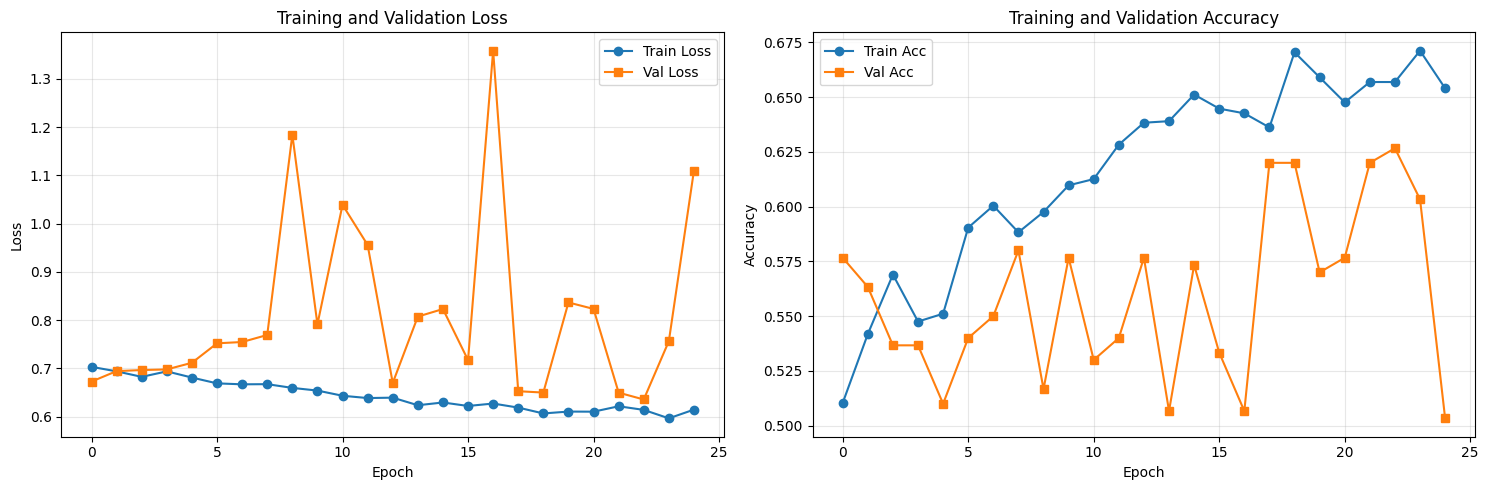

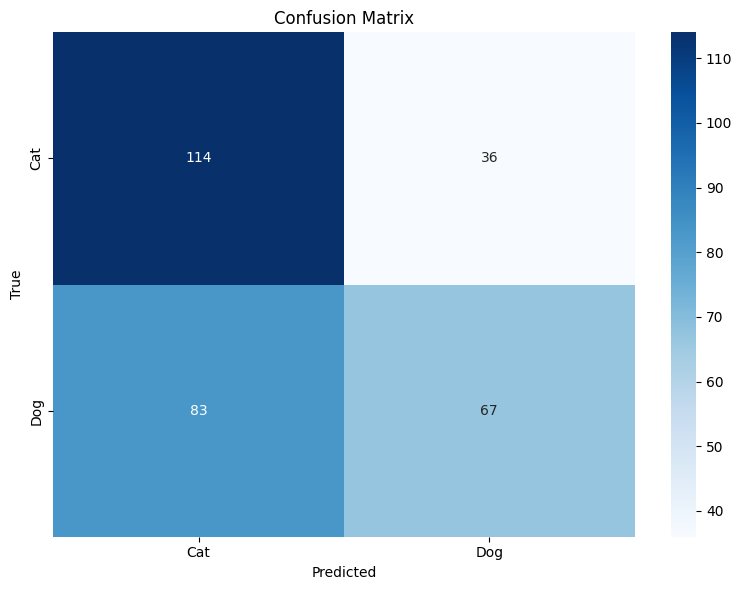


Classification Report:
              precision    recall  f1-score   support

         Cat       0.58      0.76      0.66       150
         Dog       0.65      0.45      0.53       150

    accuracy                           0.60       300
   macro avg       0.61      0.60      0.59       300
weighted avg       0.61      0.60      0.59       300


 Финальная модель сохранена: /content/final_model.pth


In [9]:
# 4. ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ

def main():
    # Настройки
    EPOCHS = 25
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    # Устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Device: {device}")

    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Инициализация модели
    model = YedroudjNet().to(device)
    print(f"\n Модель загружена на {device}")

    # Функция потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Scheduler для уменьшения learning rate (БЕЗ verbose)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
        # verbose удален - не поддерживается в старых версиях PyTorch
    )

    # История обучения
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_auc': []
    }

    # Лучшая модель
    best_val_acc = 0.0
    best_epoch = 0

    print(f"\n{'='*60}")
    print(f"НАЧАЛО ОБУЧЕНИЯ")
    print(f"{'='*60}")
    print(f"Эпох: {EPOCHS}")
    print(f"Learning rate: {LEARNING_RATE}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
    print(f"{'='*60}\n")

    # Цикл обучения
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 60)

        # Обучение
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Валидация
        val_loss, val_acc, val_auc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        # Обновление scheduler
        scheduler.step(val_loss)

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        # Вывод результатов
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, '/content/best_model.pth')
            print(f" Новая лучшая модель сохранена! (Val Acc: {val_acc:.4f})")

    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print(f"{'='*60}")
    print(f"Лучшая точность на валидации: {best_val_acc:.4f} (эпоха {best_epoch})")

    # Загрузка лучшей модели
    checkpoint = torch.load('/content/best_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n Загружена лучшая модель (эпоха {checkpoint['epoch']+1})")

    # Тестирование
    print(f"\n{'='*60}")
    print(f"ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ")
    print(f"{'='*60}")

    test_loss, test_acc, test_auc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\nTest Loss:  {test_loss:.4f}")
    print(f"Test Acc:   {test_acc:.4f}")
    print(f"Test AUC:   {test_auc:.4f}")

    # Визуализация
    print(f"\n{'='*60}")
    print(f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print(f"{'='*60}")

    plot_training_history(history)
    plot_confusion_matrix(test_labels, test_preds)

    # Сохранение финальной модели
    torch.save(model.state_dict(), '/content/final_model.pth')
    print(f"\n Финальная модель сохранена: /content/final_model.pth")

    return model, history

# Запуск обучения
if __name__ == "__main__":
    trained_model, training_history = main()

## Анализ результатов обучения Yedroudj-Net (256×256, Ч/Б)

### Детальный анализ

1. Динамика обучения

 Положительные моменты:

Точность на обучении выросла с 51.04% → 67.12% — модель способна учиться

Потери (loss) стабильно снижаются на трейне

Критические проблемы:

Сильная нестабильность: валидационная точность колеблется от 50.33% до 62.67% (разброс 12%)

Провалы на поздних эпохах: эпоха 25 показала падение до 50.33% — признак переобучения

Несоответствие трейн/вал: модель запоминает трейн, но не обобщает

Системное смещение в сторону "кошки":

Полнота для кошек: 76% (хорошо находит кошек)

Полнота для собак: 45% (плохо находит собак)

Точность для собак: 65% (когда говорит "собака" — часто права)

## Финальный вывод:

Модель работает, но результаты непрактичны для реального применения:

Архитектура функционирует корректно (нет критических ошибок)

60.33% точности недостаточно даже для базовых задач (минимум 80% для приемлемого качества)

Архитектура не предназначена для семантической классификации животных

Черно-белый формат критически ограничивает возможности модели

## Рекомендация:

Для задачи классификации кошек/собак не использовать Yedroudj-Net. Вместо этого:
Вернуть цветные изображения
Использовать предобученную архитектуру (ResNet18/34, EfficientNet-B0)
Применить transfer learning с тонкой настройкой
Ожидаемый результат: 85–90% точности на том же датасете.
Для стегоанализа (обнаружение скрытых сообщений) Yedroudj-Net остаётся отличным выбором, но для классификации животных — нет.